# Data Analysis

This script analysis the relationship between Renewable Energy Score and Renewable Share, following the step below:
1.   we will compute the Pearson correlation coefficient between the two variables,
2.   we will interpret the p-value, in order to determine statistical significance,
3.   we will, finally, visualize the data using a scatterplot.

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
from scipy.stats import pearsonr


df = pd.read_csv("../Datasets_and_maps/merged.csv")
print(df.head)
x = df['Renewable Energy score']
y = df['Renewable_Share']

# Calculate Pearson correlation coefficient and p-value
corr_coef, p_value = pearsonr(x, y)

# Print results
print(f"Pearson Correlation Coefficient: {corr_coef:.3f}")
print(f"P-value: {p_value:.5f}")

<bound method NDFrame.head of     Unnamed: 0         Country                      Region  \
0            0     Afghanistan                  South Asia   
1            1         Algeria  Middle East & North Africa   
2            2          Angola          Sub-Saharan Africa   
3            3       Argentina   Latin America & Caribbean   
4            4         Armenia       Europe & Central Asia   
..         ...             ...                         ...   
87          87  United Kingdom            OECD high income   
88          88      Uzbekistan       Europe & Central Asia   
89          89         Vietnam         East Asia & Pacific   
90          90          Zambia          Sub-Saharan Africa   
91          91        Zimbabwe          Sub-Saharan Africa   

           Income group  Renewable Energy score  Total_Capacity_MW  \
0            Low income               26.934385          300.55000   
1   Upper middle income               51.101032        15873.80000   
2   Upper middl

The correlation value obtained from the data is very close to 0, indicating no meaningful linear relationship between Renewable Energy Score and Renewable Share.
The slight negative value suggests a very weak negative trend, but it’s so small that it is likely due to random variation.

The p-value is less then 0.05: this means that the correlation is not statistically significant. We cannot reject the null hypothesis, which states that no correlation exists between the two variables.

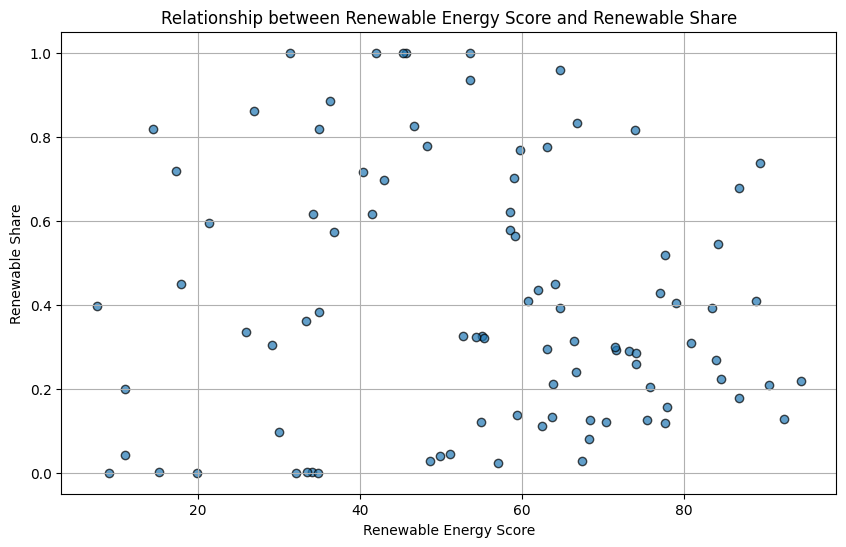

In [3]:
# Scatterplot
plt.figure(figsize=(10, 6))
plt.scatter(x, y, alpha=0.7, edgecolors='k')
plt.title('Relationship between Renewable Energy Score and Renewable Share')
plt.xlabel('Renewable Energy Score')
plt.ylabel('Renewable Share')
plt.grid(True)
plt.show()

The scatterplot shows that the points are widely scattered across the plot with no obvious upward or downward slope. This visual pattern aligns with the very weak Pearson correlation (-0.080), suggesting that as policy scores increase, renewable share doesn’t consistently increase or decrease.
The Renewable Share values vary widely, meaning even among countries with strong policies, renewable deployment levels differ greatly.

The records that appear in the top-left quadrant (low policy score, high renewable share) represent countries that might have high renewable capacity not driven by policy, but by natural resource availability (e.g., countries with abundant hydro or geothermal resources).

Conversely, some countries fall in the bottom-right quadrant (high policy score, low renewable share), indicating the possibility of a recent policy adoption (where insfrastructure hasn't caught up yet), or implementation challenges (like lack of funding, political will, or grid capacity).

In the mid-range there's no clear concentration or trend. This may suggest inconsistent policy enforcement or mixed national circumstances.

The scatter plot confirms that strong renewable policies (as measured by RISE) do not automatically lead to high renewable energy deployment. Real-world implementation appears to depend on additional factors beyond policy alone.

## Analysis based on Income group

The moderate strength of the correlation implies that policy alone does not fully explain renewable deployment outcomes, highlighting the need for further analysis, such as breaking down results by income group.

For our purpose we are going to calculate the Pearson correlation and p-value between Renewable Energy Score and Renewable Share, grouped by income level.


In [10]:
# Create an empty dictionary to store results
correlation_results = {}

# Loop over each unique income group
for group in df['Income group'].unique():
    subset = df[df['Income group'] == group]

    # Make sure there are enough data points for a correlation test
    if len(subset) > 2:
        r, p = pearsonr(subset['Renewable Energy score'], subset['Renewable_Share'])
        correlation_results[group] = {
            'Pearson Correlation': round(r, 3),
            'P-value': round(p, 5),
            'N': len(subset)
        }
    else:
        correlation_results[group] = {
            'Pearson Correlation': 'Insufficient data',
            'P-value': None,
            'N': len(subset)
        }

# Convert to a DataFrame for easy viewing
correlation_df = pd.DataFrame.from_dict(correlation_results, orient='index')
correlation_df

,Pearson Correlation,P-value,N
Low income,0.585,0.00422,22
Upper middle income,-0.124,0.60157,20
High income,0.517,0.00809,25
Lower middle income,-0.090,0.66976,25


### Low income

Contries with a lower income present a strong and significant correlation (r = 0.585, p < 0.01).
This suggests policy efforts are translating well into renewable deployment in these countries. Possible reason for this kind of outcome is the focused international funding or smaller grid systems where policy has more leverage.

### Upper middle income and lower middle income

In the case of upper and middle income the correlations are weak and not statistically significant. Possible explanations could be the following:
*   policy is not yet effectively implemented, so therer is a gap between design and enforcement,
*   structural challanges obstacle the implementation of the policy (e.g., grid limitations, financing gaps),
*   greater reliance on transitional fuels like natural gas prevent renewable energy sources from being used.

### High income

The countries with a high income demonstrate a moderate positive correlation, also significant. This indicates that policy frameworks still matter in these countries, even though they may already have mature energy infrastructure.

However, other factors like innovation, market forces, or public opinion may also play a relevant role.

### Scatterplot

For a better understanding of the findings, we will visualize the data using 4 different scatterplot, one for each income group.

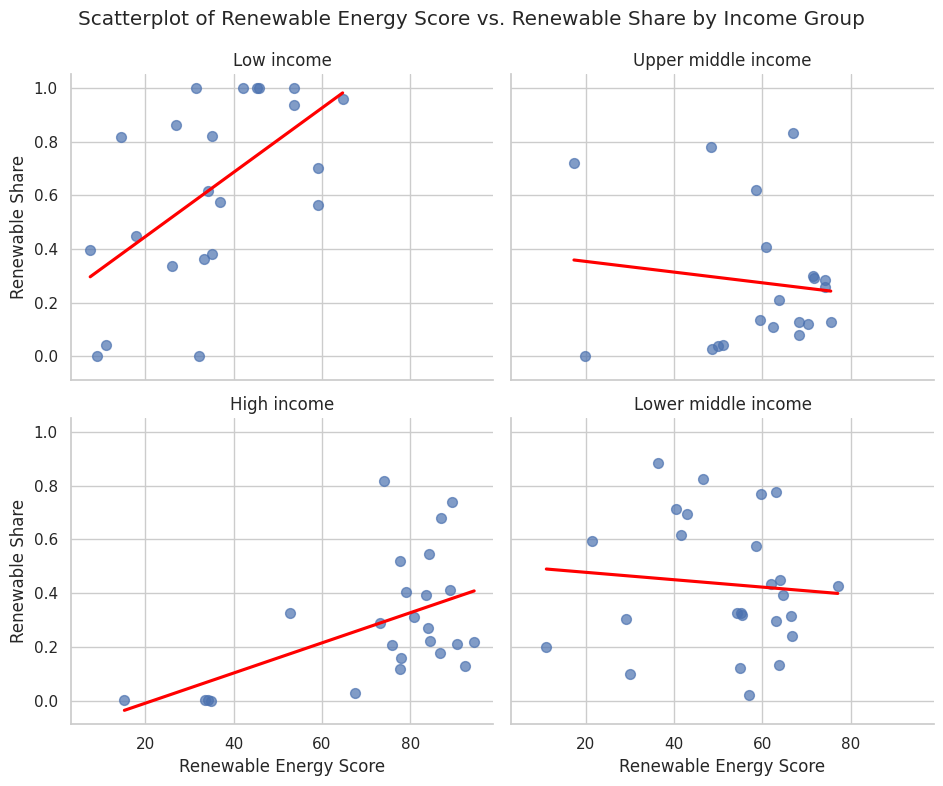

In [11]:
import seaborn as sns

# Set Seaborn style
sns.set(style="whitegrid")

# Create a FacetGrid for each Income group
g = sns.FacetGrid(df, col="Income group", col_wrap=2, height=4, aspect=1.2)

# Map the scatterplot and regression line
g.map_dataframe(sns.regplot,
                x="Renewable Energy score",
                y="Renewable_Share",
                scatter_kws={"s": 50, "alpha": 0.7},
                line_kws={"color": "red"},
                ci=None)

# Add titles and labels
g.set_axis_labels("Renewable Energy Score", "Renewable Share")
g.set_titles(col_template="{col_name}")

plt.subplots_adjust(top=0.9)
g.fig.suptitle("Scatterplot of Renewable Energy Score vs. Renewable Share by Income Group")

plt.show()


From the scatterplots we can get some key insights:
* Policy effectiveness appears highest in Low and High Income countries, where correlation is significant.
* Middle-income countries show little or no correlation, suggesting that non-policy factors may dominate.